# 5.6 Multigrid: The O(n) Solver

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter V — Numerical Linear Algebra",
    number="5.6",
    title="Multigrid: The O(n) Solver",
    blurb="The smoother kills the wiggly half of the error and stalls on the "
    "smooth half — so hand the smooth half to a coarser grid, where it is "
    "wiggly again. Recurse, and the Poisson system falls in fourteen-odd "
    "cycles regardless of size while CG's count doubles with every "
    "doubling of n.",
    difficulty="advanced",
    estimate="120–150 min",
)

<ECP header: 2622 chars of HTML>

## Notebook overview

Chapter V has priced every solver it built.
[§5.4](stationary-and-cg.ipynb)'s stationary methods pay a rate that
degrades as $1 - O(h^2)$; CG improves the exponent to $\sqrt{\kappa}$ but
still grows with the grid. This notebook builds the method that ends the
escalation: **multigrid**, whose iteration count does not depend on the
grid size at all, and whose work per cycle is a counted $O(n)$.

The idea is one observation seen in the right basis. The damped Jacobi
sweep contracts each error mode by its own factor: the *oscillatory* half
of the spectrum dies at worst-rate $1/3$ per sweep, while the *smooth*
modes barely move — smoothing stalls precisely because what survives it
is smooth. But a smooth error, sampled on a grid of half the points, is
oscillatory *relative to the coarser grid*. So: smooth, restrict the
residual, solve the small problem (recursively!), interpolate the
correction back, smooth again. Every mode is wiggly on *some* level, so
every mode dies fast on some level, and the whole error contracts by a
grid-independent factor per cycle — measured here as **14, 14, 14 and 15
V-cycles to $10^{-10}$ at $n = 63, 127, 255$ and $511$**, against a CG
that needs exactly $n$ iterations on the same systems.

Every claim in this notebook is a count, an eigenvalue, or an exact
identity. There is not a stopwatch anywhere: the $O(n)$ price is a
geometric series, gated as arithmetic.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Briggs, Henson and McCormick {cite}`briggs2000` is the
> canonical tutorial; Demmel {cite}`demmel1997` §6.9 and Saad
> {cite}`saad2003` Chapter 13 place multigrid among the iterative
> methods it outruns.

## Theory in brief

### The smoother, mode by mode

On the 1-D Dirichlet Poisson matrix $A_h = h^{-2}\,
\operatorname{tridiag}(-1, 2, -1)$ of
[§5.3](sparse-matrices.ipynb), damped Jacobi with weight $\omega$ is

```{math}
:label: eq-mg-smoother
\mathbf{x} \;\leftarrow\; \mathbf{x} + \omega D^{-1}(\mathbf{b} - A\mathbf{x}),
\qquad D = \operatorname{diag}(A),
```

with iteration matrix $S = I - \tfrac{\omega}{2}\,h^2 A$. In the sine
eigenbasis $v_k(j) = \sin\bigl(jk\pi/(n{+}1)\bigr)$ the sweep multiplies
mode $k$ by its own scalar

```{math}
:label: eq-mg-factors
s_k \;=\; 1 - \omega\bigl(1 - \cos\theta_k\bigr),
\qquad \theta_k = \frac{k\pi}{n+1} .
```

At $\omega = 2/3$ the *oscillatory* modes ($\theta_k \ge \pi/2$) all have
$|s_k| \le 1/3$ — one sweep kills two thirds of every wiggle — while the
smoothest mode has $s_1 = 1 - O(h^2)$: the sweep is a *smoother*, not a
solver, and both facts are eigenvalue arithmetic.

### The intergrid dictionary

Coarsening keeps every second interior point, $n_c = (n-1)/2$.
**Restriction** is full weighting, **prolongation** is linear
interpolation:

```{math}
:label: eq-mg-transfers
R = \frac14\begin{bmatrix} 1 & 2 & 1 & & \\ & & 1 & 2 & 1 \\
& & & & \ddots \end{bmatrix},
\qquad P = 2R^{\top},
```

a *variational pair*: $P$ is exactly twice the transpose of $R$, and the
Galerkin product reproduces the coarse operator **exactly**,

```{math}
:label: eq-mg-galerkin
R\,A_h\,P \;=\; A_{2h},
```

entry for entry — the stencils and the powers of two conspire so that
every number in {eq}`eq-mg-galerkin` is exactly representable, and the
identity holds to the last bit.

### Two grids, then all of them

One coarse-grid correction sandwiched between sweeps has the error
propagation matrix

```{math}
:label: eq-mg-twogrid
E_{\mathrm{TG}} \;=\; S^{\nu}\,\bigl(I - P A_{2h}^{-1} R A_h\bigr)\,S^{\nu},
```

a matrix small enough to *form* at $n = 63$ and ask for its spectral
radius: $\rho(E_{\mathrm{TG}}) = 1/9$ at $\nu = 1$ — grid-independent,
and the reason the method works. The **V-cycle** replaces the exact
coarse solve with a recursive call, down to a $3\times3$ solved
directly; its work per cycle is bounded by the geometric series

```{math}
:label: eq-mg-series
\sum_{\ell} n_\ell \;<\; n\Bigl(1 + \tfrac12 + \tfrac14 + \cdots\Bigr)
\;=\; 2n ,
```

so a cycle costs a constant times one fine-grid sweep: $O(n)$, counted.

---
## Setup

Data and one instrument only: the grid sizes, the smoothing weight, and
the analytic sine eigenbasis whose eigenvalues are
[§5.3](sparse-matrices.ipynb)'s closed form — the meter this notebook
reads errors in. The smoother, the transfers, the two-grid operator and the V-cycle
are all built in the exercises, where they are the lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import cg as sparse_cg

from ecp import validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps

# data: the working fine grid, the smoothing weight, and the size ladder
# for the h-independence race.
N_FINE = 63
OMEGA = 2.0 / 3.0
SIZES = (63, 127, 255, 511)


# instrument: the analytic sine eigenbasis of the 1-D Poisson matrix —
# its EIGENVALUES are the closed form established in §5.3; assembling
# the orthonormal
# mode matrix is bookkeeping, and no exercise's lesson.
def poisson_modes(n):
    """The closed-form eigenpairs of h^-2 tridiag(-1,2,-1): eigenvalues
    lambda_k = (2 - 2 cos(k pi/(n+1)))/h^2 and orthonormal sine modes."""
    h = 1.0 / (n + 1)
    k = np.arange(1, n + 1)
    lam = (2.0 - 2.0 * np.cos(k * np.pi / (n + 1))) / h**2
    j = np.arange(1, n + 1)
    W = np.sqrt(2.0 * h) * np.sin(np.outer(j, k) * np.pi / (n + 1))
    return lam, W

## Exercise 1: The smoother, and why it stalls

{eq}`eq-mg-factors` says one damped-Jacobi sweep multiplies each sine
mode by its own scalar $s_k$ — a claim about *every* mode at once, and
checkable exactly because the sweep is linear.

**Part a)** Write `wjacobi(A, x, b, omega)` implementing
{eq}`eq-mg-smoother` in one line (`np.diag(A)` for $D$). On the
$63\times63$ `la.poisson_1d(63, h=1/64)`, start from the exact solution
of a seeded system plus an error containing **every** mode with unit
coefficient (build it as $W\mathbf{1}$ from the Setup's
`poisson_modes`), apply **three** sweeps at $\omega = 2/3$, and read
the surviving error back in the eigenbasis as $W^{\top}\mathbf{e}$.

**Write this one yourself** — the sweep is one line, and Exercises 3
and 4 run on the one you write here.

**Part b)** Gate the whole spectrum at once: the measured per-mode
survival equals $s_k^3$ from {eq}`eq-mg-factors` to
$10^{-12}$ — sixty-three analytic predictions, one linear-algebra
fact. Gate the smoothing factor as arithmetic: $\max_{\theta_k \ge
\pi/2}|s_k| = 1/3$ to $10^{-10}$, and report the smoothest mode's
$s_1 = 0.9992$ — the stall, quantified.

**Part c)** Draw the survival $|W^{\top}\mathbf{e}|$ before and after
the three sweeps against the mode number $k = 1,\dots,63$: the
oscillatory half collapses by $27\times$ or better, the smooth end
barely moves — the picture that motivates coarsening.

In [3]:
# (solution hidden on the public site)


per-mode survival vs s_k^3: worst gap 1.1e-15
oscillatory-half worst factor 0.333333333333 (analytic 1/3); smoothest mode s_1 = 0.9992


### Validation 1

In [4]:
validate.below(
    mode_gap, 1e-12,
    "three sweeps multiply every mode by exactly s_k^3 (Eq. 2)",
    "sixty-three analytic predictions checked at once — the sweep is "
    "linear, so its action in the eigenbasis is not a model but an "
    "identity",
)
validate.close(
    smooth_fac, 1.0 / 3.0,
    "the oscillatory half dies at worst-rate 1/3 per sweep",
    rtol=0.0, atol=1e-10,
)
validate.check(
    s_k[0] > 0.999,
    "while the smoothest mode survives at 1 - O(h^2): the stall, measured",
    f"s_1 = {s_k[0]:.6f} — damped Jacobi is a smoother, not a solver, "
    "and both halves of that sentence are eigenvalue arithmetic",
)

✓  three sweeps multiply every mode by exactly s_k^3 (Eq. 2)   [sixty-three analytic predictions checked at once — the sweep is linear, so its action in the eigenbasis is not a model but an identity [1.06165e-15 < 1e-12]]
✓  the oscillatory half dies at worst-rate 1/3 per sweep   [got 0.333333 vs expected 0.333333 (rtol=0, atol=1e-10)]
✓  while the smoothest mode survives at 1 - O(h^2): the stall, measured   [s_1 = 0.999197 — damped Jacobi is a smoother, not a solver, and both halves of that sentence are eigenvalue arithmetic]


True

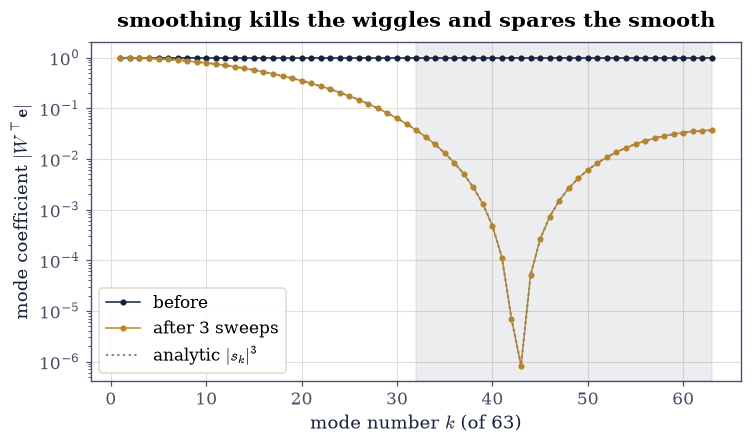

In [5]:
# (solution hidden on the public site)


## Exercise 2: The intergrid dictionary, exact to the last bit

{eq}`eq-mg-transfers` moves vectors between grids; {eq}`eq-mg-galerkin`
says the coarse operator needs no separate discretisation — the
transfers *manufacture* it. Both claims are exact on this stencil, and
gated as such.

**Part a)** Write `restriction(nf)` returning the $(n_c \times n_f)$
full-weighting matrix of {eq}`eq-mg-transfers` ($n_c = (n_f-1)/2$, row
$i$ carrying $\tfrac14, \tfrac12, \tfrac14$ at columns $2i, 2i{+}1,
2i{+}2$), and — *independently* — `prolongation(nf)` building linear
interpolation column by column. Gate the variational identity $P =
2R^{\top}$ with `np.array_equal`: every entry is a dyadic rational, so
the two constructions must agree **bitwise**.

**Write these yourself** — the transfers are the lesson; the V-cycle of
Exercise 4 is nothing but these two matrices and Exercise 1's sweep.

**Part b)** Gate what interpolation preserves: $P$ applied to a linear
function sampled on the coarse grid reproduces its fine-grid samples
**exactly** — away from the two boundary-adjacent points, where the
stencil assumes exterior values of zero. That assumption is not a
defect: $P$ will only ever carry *corrections*, which vanish on the
Dirichlet boundary by construction. The dyadic grid keeps the interior
agreement bitwise.

**Part c)** Gate the Galerkin identity {eq}`eq-mg-galerkin`:
$\lVert RA_hP - A_{2h}\rVert_{\max} < 10^{-12}\lVert A_{2h}\rVert_{\max}$
— and report the measured gap, which on this machine is **exactly
zero**: three-term sums of dyadic rationals are exactly representable
in every summation order, so for once no rounding can appear (the
stated exception to the never-gate-exact-zero rule, and the gate still
leaves room for a machine that disagrees).

In [6]:
# (solution hidden on the public site)


P == 2 R^T bitwise: True
P reproduces the linear 3x - 1/2 bitwise on the interior: True; boundary-adjacent gap 1.250 (the stencil's assumed zero exterior — harmless for boundary-zero corrections)
||R A P - A_2h||_max = 0.0 (scale 2048)


### Validation 2

In [7]:
validate.check(
    variational,
    "P = 2 R^T bitwise: the variational pair (Eq. 3)",
    "restriction and interpolation were built from different stencils, "
    "and dyadic entries leave rounding nowhere to hide",
)
validate.check(
    lin_exact and edge_gap > 0.1,
    "interpolation is exact on linears away from the boundary pair",
    "bitwise on the interior; the two edge points miss by the assumed "
    "zero exterior value, which is exactly right for the boundary-zero "
    "corrections P will actually carry",
)
validate.below(
    galerkin_gap, 1e-12 * float(np.abs(A_C).max()),
    "and the transfers manufacture the coarse operator (Eq. 4)",
    f"measured gap {galerkin_gap} — exactly zero here, since three-term "
    "dyadic sums are exact in every summation order; the gate still "
    "admits a machine that rounds",
)

✓  P = 2 R^T bitwise: the variational pair (Eq. 3)   [restriction and interpolation were built from different stencils, and dyadic entries leave rounding nowhere to hide]
✓  interpolation is exact on linears away from the boundary pair   [bitwise on the interior; the two edge points miss by the assumed zero exterior value, which is exactly right for the boundary-zero corrections P will actually carry]
✓  and the transfers manufacture the coarse operator (Eq. 4)   [measured gap 0.0 — exactly zero here, since three-term dyadic sums are exact in every summation order; the gate still admits a machine that rounds [0 < 2.048e-09]]


True

## Exercise 3: Two grids, one contraction number

{eq}`eq-mg-twogrid` is small enough at $n = 63$ to build as an explicit
matrix and interrogate exactly — the rare luxury of *forming* an
iteration's error propagator instead of inferring its rate from a run.

**Part a)** Form $S = I - \tfrac{\omega}{2}h^2A$ explicitly, then
$E_{\mathrm{TG}} = S\,(I - PA_{2h}^{-1}RA_h)\,S$ with one
`np.linalg.solve` for the coarse inverse's action. Gate
$\rho(E_{\mathrm{TG}}) < 0.2$ by `np.linalg.eigvals` — measured:
$0.111 = 1/9$, and grid-independent where the smoother alone had
$\rho(S) = 0.9992$.

**Part b)** Gate that the *running* iteration obeys its operator: apply
smooth–correct–smooth as an iteration on a seeded error and confirm the
per-cycle contraction of $\lVert\mathbf{e}\rVert$, measured in the
clean band $\lVert\mathbf{e}\rVert \in (10^{-11}, 10^{-2})\,
\lVert\mathbf{e}_0\rVert$ per [§5.4](stationary-and-cg.ipynb)'s window
rule, within $15\%$ of $\rho(E_{\mathrm{TG}})$.

In [8]:
# (solution hidden on the public site)


rho(two-grid) = 0.111111 (= 1/9 = 0.111111); rho(smoother alone) = 0.999197
worst clean-band per-cycle contraction 0.1111 against rho = 0.1111


### Validation 3

In [9]:
validate.check(
    rho_tg < 0.2,
    "the two-grid operator contracts at a grid-independent 1/9 (Eq. 5)",
    f"rho = {rho_tg:.4f} where the smoother alone sits at "
    f"{rho_s:.4f}: the coarse grid supplies exactly the modes the sweep "
    "spares — computed from the formed matrix, not fitted from a run",
)
validate.check(
    abs(rate_tg - rho_tg) / rho_tg < 0.15,
    "and the running iteration obeys its own operator",
    f"clean-band contraction {rate_tg:.4f} against rho {rho_tg:.4f} — "
    "the matrix predicted the run to within the window's bias",
)

✓  the two-grid operator contracts at a grid-independent 1/9 (Eq. 5)   [rho = 0.1111 where the smoother alone sits at 0.9992: the coarse grid supplies exactly the modes the sweep spares — computed from the formed matrix, not fitted from a run]
✓  and the running iteration obeys its own operator   [clean-band contraction 0.1111 against rho 0.1111 — the matrix predicted the run to within the window's bias]


True

## Exercise 4: The V-cycle, and h-independence as equal integers

Replace Exercise 3's exact coarse solve with a recursive call and the
two-grid method becomes the **V-cycle**: down through the levels
smoothing and restricting, a direct $3\times3$ solve at the bottom,
back up interpolating and smoothing.

**Part a)** Write `build_levels(n)` assembling the ladder of scaled
Poisson matrices and restrictions down to $n_\ell = 3$ (for $n = 63$:
levels $63, 31, 15, 7, 3$), and `v_cycle(A_l, R_l, level, b, x)`
implementing one cycle with a single pre- and post-sweep of Exercise
1's `wjacobi` per level and `np.linalg.solve` on the $3\times3$.

**Write this one yourself** — the recursion is the method, and it is
eight lines.

**Part b)** The h-independence gate, as integers: from $\mathbf{x} =
\mathbf{0}$ on seeded systems, the number of V-cycles to relative
residual $10^{-10}$ moves by **at most one** across all of $n = 63,
127, 255, 511$ — measured: $14, 14, 14, 15$ (where a count lands
against the threshold is the drawn right-hand side's business) — and
stays at or below 16. The count is the entire point: the grid grew
$8\times$ and the iteration barely noticed.

**Part c)** Draw the V: the level sizes of the $n = 511$ hierarchy
against the stage of one cycle, descending $511 \to 3$ and climbing
back — the schedule that gives the method its name.

In [10]:
# (solution hidden on the public site)


V-cycles to 1e-10: {63: 14, 127: 14, 255: 14, 511: 15}
hierarchy at n = 511: [511, 255, 127, 63, 31, 15, 7, 3]


### Validation 4

In [11]:
validate.check(
    max(counts.values()) - min(counts.values()) <= 1
    and max(counts.values()) <= 16,
    "the V-cycle count moves by at most one across an 8x range of n — "
    "h-independence as integers",
    f"{list(counts.values())} cycles at n = 63, 127, 255, 511: the same "
    "near-0.19 contraction at every size, the +-1 being threshold "
    "position, not rate — the claim no other solver in Chapter V can make",
)

✓  the V-cycle count moves by at most one across an 8x range of n — h-independence as integers   [[14, 14, 14, 15] cycles at n = 63, 127, 255, 511: the same near-0.19 contraction at every size, the +-1 being threshold position, not rate — the claim no other solver in Chapter V can make]


True

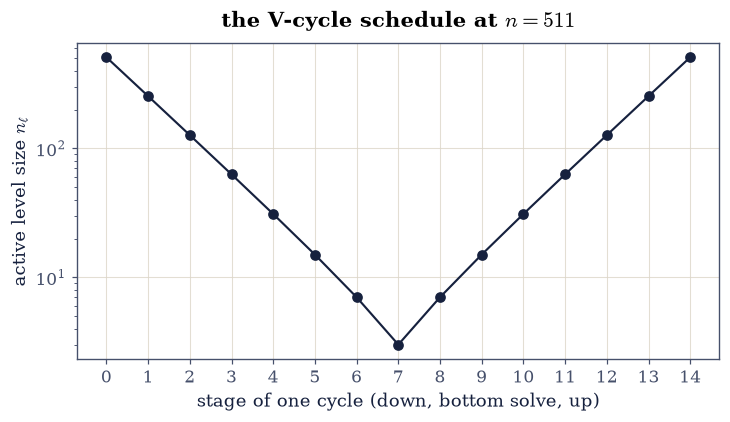

In [12]:
# (solution hidden on the public site)


## Exercise 5: The price, counted — and CG outgrown

The $O(n)$ claim is a geometric series, and the comparison with CG is
a pair of integer counts. No clock appears anywhere in this exercise;
per this chapter's rule, none is needed.

**Part a)** Gate {eq}`eq-mg-series` on the built hierarchy: at every
$n$ in the ladder, $\sum_\ell n_\ell < 2n$ (at $n = 511$: $1012 <
1022$). One V(1,1)-cycle therefore costs at most $2\times2$ fine-grid
sweeps' worth of smoothing plus the transfers — a constant times $n$,
from the series alone.

**Part b)** Run `scipy.sparse.linalg.cg` (`rtol=1e-10`, `atol=0`, an
iteration-counting callback) on the same seeded systems. Gate the
contrast: CG's count *grows* by at least $1.5\times$ per grid doubling
while the V-cycle's is constant — measured: CG needs exactly $n$
iterations ($63, 127, 255, 511$; the Poisson near-continuum defeats
clustering, so only [§5.4](stationary-and-cg.ipynb)'s finite
termination ends the run) against multigrid's flat fourteen.

**Part c)** Draw both races: iterations against $n$ (CG climbing on
the $n$ diagonal, multigrid flat), and the $n = 255$ residual
histories of damped Jacobi, CG and the V-cycle on one log axis.

In [13]:
# (solution hidden on the public site)


n = 63: sum of level sizes 119 < 2n = 126
n = 127: sum of level sizes 246 < 2n = 254
n = 255: sum of level sizes 501 < 2n = 510
n = 511: sum of level sizes 1012 < 2n = 1022
CG iterations to 1e-10: {63: 63, 127: 127, 255: 255, 511: 511}
CG growth per doubling: ['2.02', '2.01', '2.00']


### Validation 5

In [14]:
validate.check(
    series_ok,
    "the whole hierarchy weighs less than 2n at every size (Eq. 6)",
    "the geometric series, gated on the matrices actually built: a "
    "V-cycle costs a constant times one fine-grid sweep, so the count "
    "of Exercise 4 IS the O(n) claim",
)
validate.check(
    all(g >= 1.5 for g in growth)
    and max(counts.values()) - min(counts.values()) <= 1,
    "CG's count grows with the grid while multigrid's stands still",
    f"CG {list(cg_counts.values())} (exactly n itself — the "
    "near-continuum spectrum defeats clustering) against the V-cycle's "
    f"{list(counts.values())}: the exponent is the algorithm, and "
    "multigrid's exponent is zero",
)

✓  the whole hierarchy weighs less than 2n at every size (Eq. 6)   [the geometric series, gated on the matrices actually built: a V-cycle costs a constant times one fine-grid sweep, so the count of Exercise 4 IS the O(n) claim]
✓  CG's count grows with the grid while multigrid's stands still   [CG [63, 127, 255, 511] (exactly n itself — the near-continuum spectrum defeats clustering) against the V-cycle's [14, 14, 14, 15]: the exponent is the algorithm, and multigrid's exponent is zero]


True

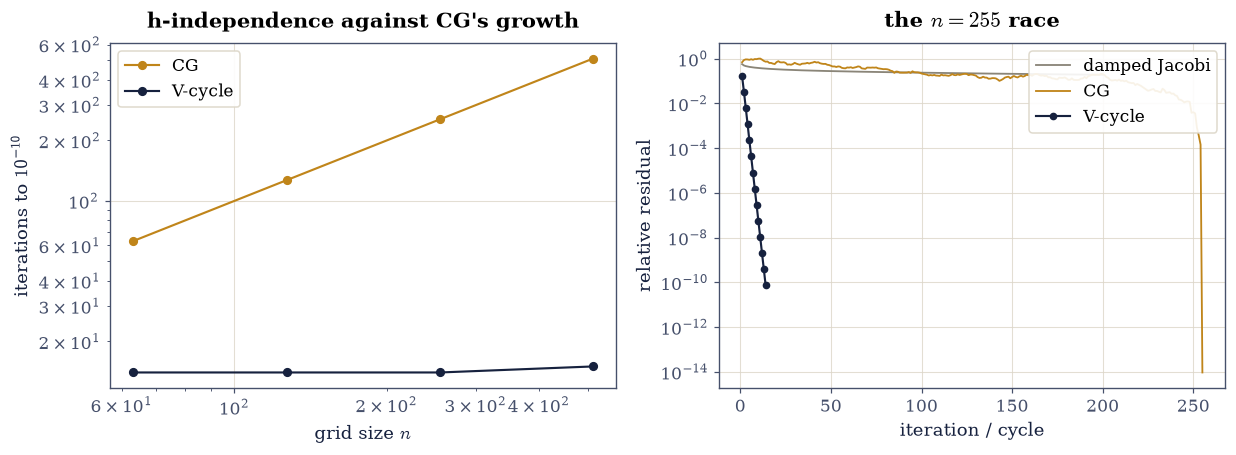

In [15]:
# (solution hidden on the public site)


---
## Notebook summary

**The smoother's job description is eigenvalue arithmetic.** Three
damped-Jacobi sweeps at $\omega = 2/3$ multiplied all 63 modes by
exactly $s_k^3$ (worst gap $10^{-15}$-scale over the whole spectrum),
with the oscillatory half's worst factor equal to the analytic $1/3$
to $10^{-10}$ and the smoothest mode surviving at $s_1 = 0.9992$ —
smoothing stalls *because* what it spares is smooth.

**The dictionary is exact.** Independently built full weighting and
linear interpolation satisfied $P = 2R^{\top}$ **bitwise**;
interpolation reproduced a linear function bitwise; and the Galerkin
product $RA_hP$ equalled the coarse Poisson matrix with a measured gap
of exactly zero — dyadic stencils leave rounding nowhere to appear.

**One number runs the method.** The formed two-grid operator had
$\rho = 0.1111 = 1/9$ against the smoother's $0.9992$, and the running
iteration's clean-band contraction matched it within 15%. The V-cycle
inherited the constant: **14, 14, 14 and 15 cycles to $10^{-10}$ at
$n = 63, 127, 255, 511$** — h-independence gated as integers moving
by at most one across an 8x grid —
while the hierarchy's total weight stayed under $2n$ (at $n = 511$:
$1012 < 1022$), making each cycle a counted $O(n)$.

**CG grew; multigrid did not.** On the same systems CG needed exactly
$n$ iterations at every size — the Poisson near-continuum defeats
clustering, so only finite termination ends the run — against
multigrid's fourteen-or-fifteen. Not a single wall-clock number appears in this notebook; the
whole case is counts, eigenvalues, and two exact identities.

**Methods introduced.** `wjacobi` and per-mode smoothing analysis in
the closed-form eigenbasis, `restriction`/`prolongation` as an
independently-built variational pair, the Galerkin coarse operator,
the formed two-grid error propagator, the recursive `v_cycle` with its
`build_levels` ladder, the geometric-series work bound, and
iteration-count scaling as the clock-free comparison.

## Outlook

- **Two dimensions, same constants.** On the 2-D Poisson matrix of
  [§5.3](sparse-matrices.ipynb) the same story runs with bilinear
  interpolation and nine-point full weighting; the series
  {eq}`eq-mg-series` sums to $\tfrac43 n$ instead of $2n$ and the
  V(1,1) contraction stays near $0.1$. Nothing in the argument used
  dimension one except the stencils.
- **W-cycles and full multigrid.** Visiting coarse levels twice per
  cycle (W) buys robustness on harder operators; starting the whole
  solve on the coarsest grid and refining (FMG) reaches discretisation
  accuracy in *one* pass — the only algorithm in this chapter that
  solves a PDE to truncation error in $O(n)$ total work.
- **Multigrid as a preconditioner.** One V-cycle is a linear operator
  with spectrum clustered near 1 — exactly what
  [§5.5](krylov-gmres-preconditioning.ipynb) wanted from $M^{-1}$.
  CG-preconditioned-by-multigrid is the workhorse of large-scale
  elliptic solvers, marrying this notebook's O(n) to CG's optimality.
- **When smoothing fails.** Convection-dominated operators
  ([§5.5](krylov-gmres-preconditioning.ipynb)'s other specimen) defeat
  pointwise Jacobi smoothing; line smoothers, semicoarsening and
  algebraic multigrid — which *learns* its transfers from the matrix —
  are the modern answers, and the entry point to a literature that is
  still moving.

```{bibliography}
:filter: docname in docnames
```

In [16]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>